# 1. Creación del índice mediante el wizard

## Creación del recurso en Azure Portal

1. En el recurso de Azure AI Search seleccionamos "Import data".
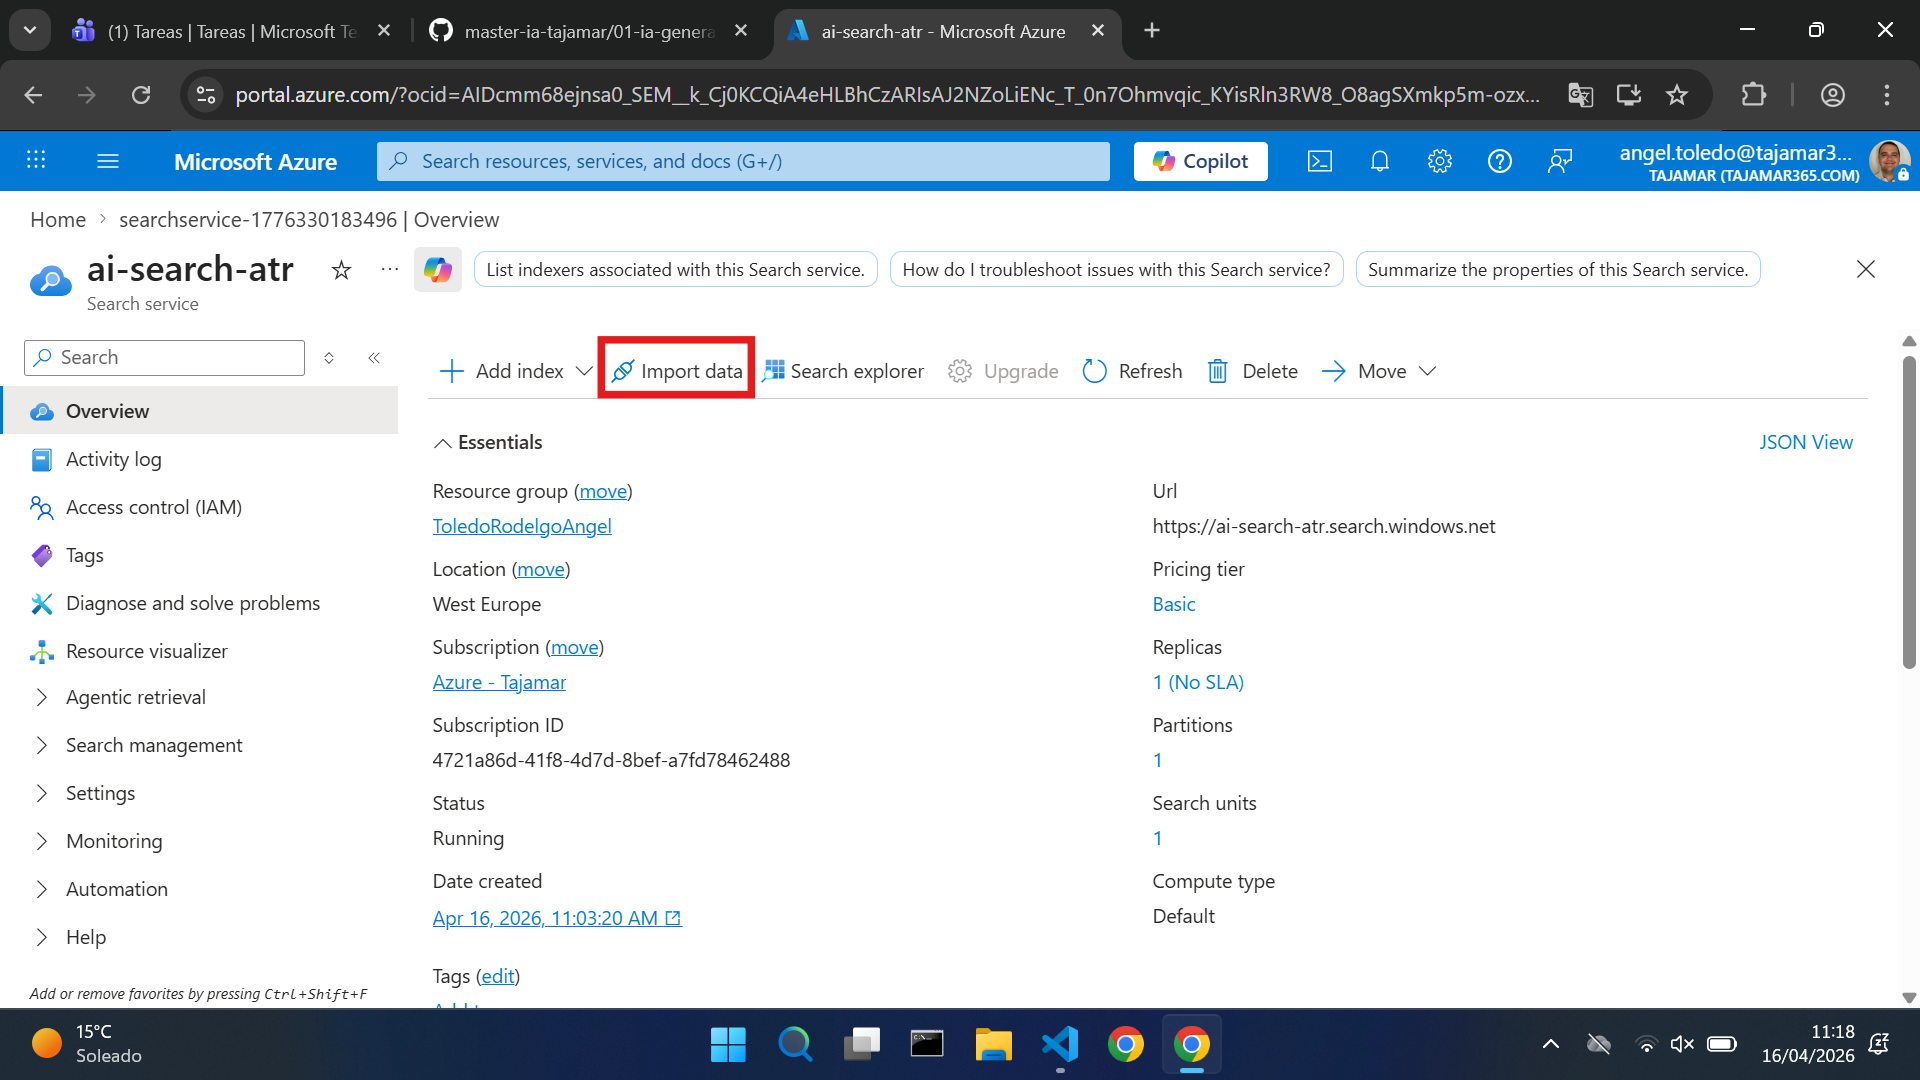

2. Seleccionamos el tipo de almacenamiento que queremos conectar.
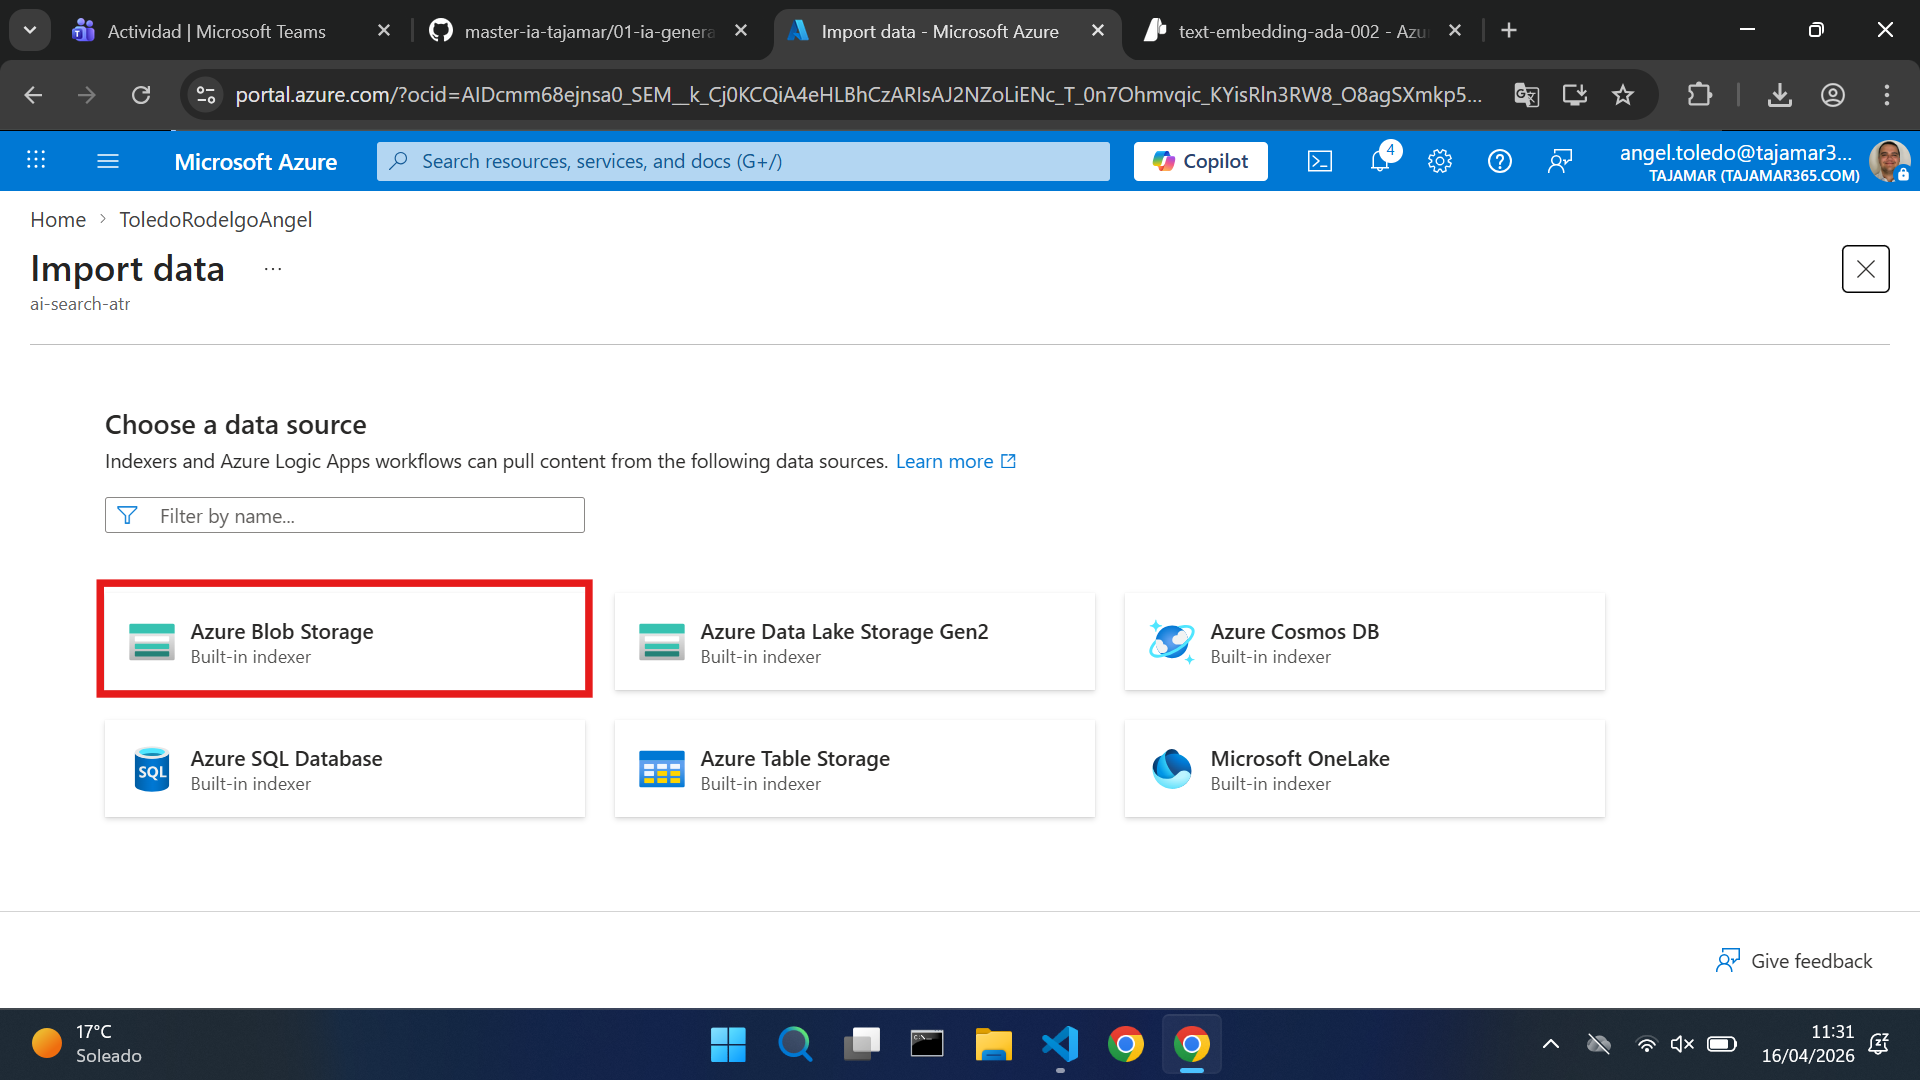

3. Elegimos el escenario "RAG".
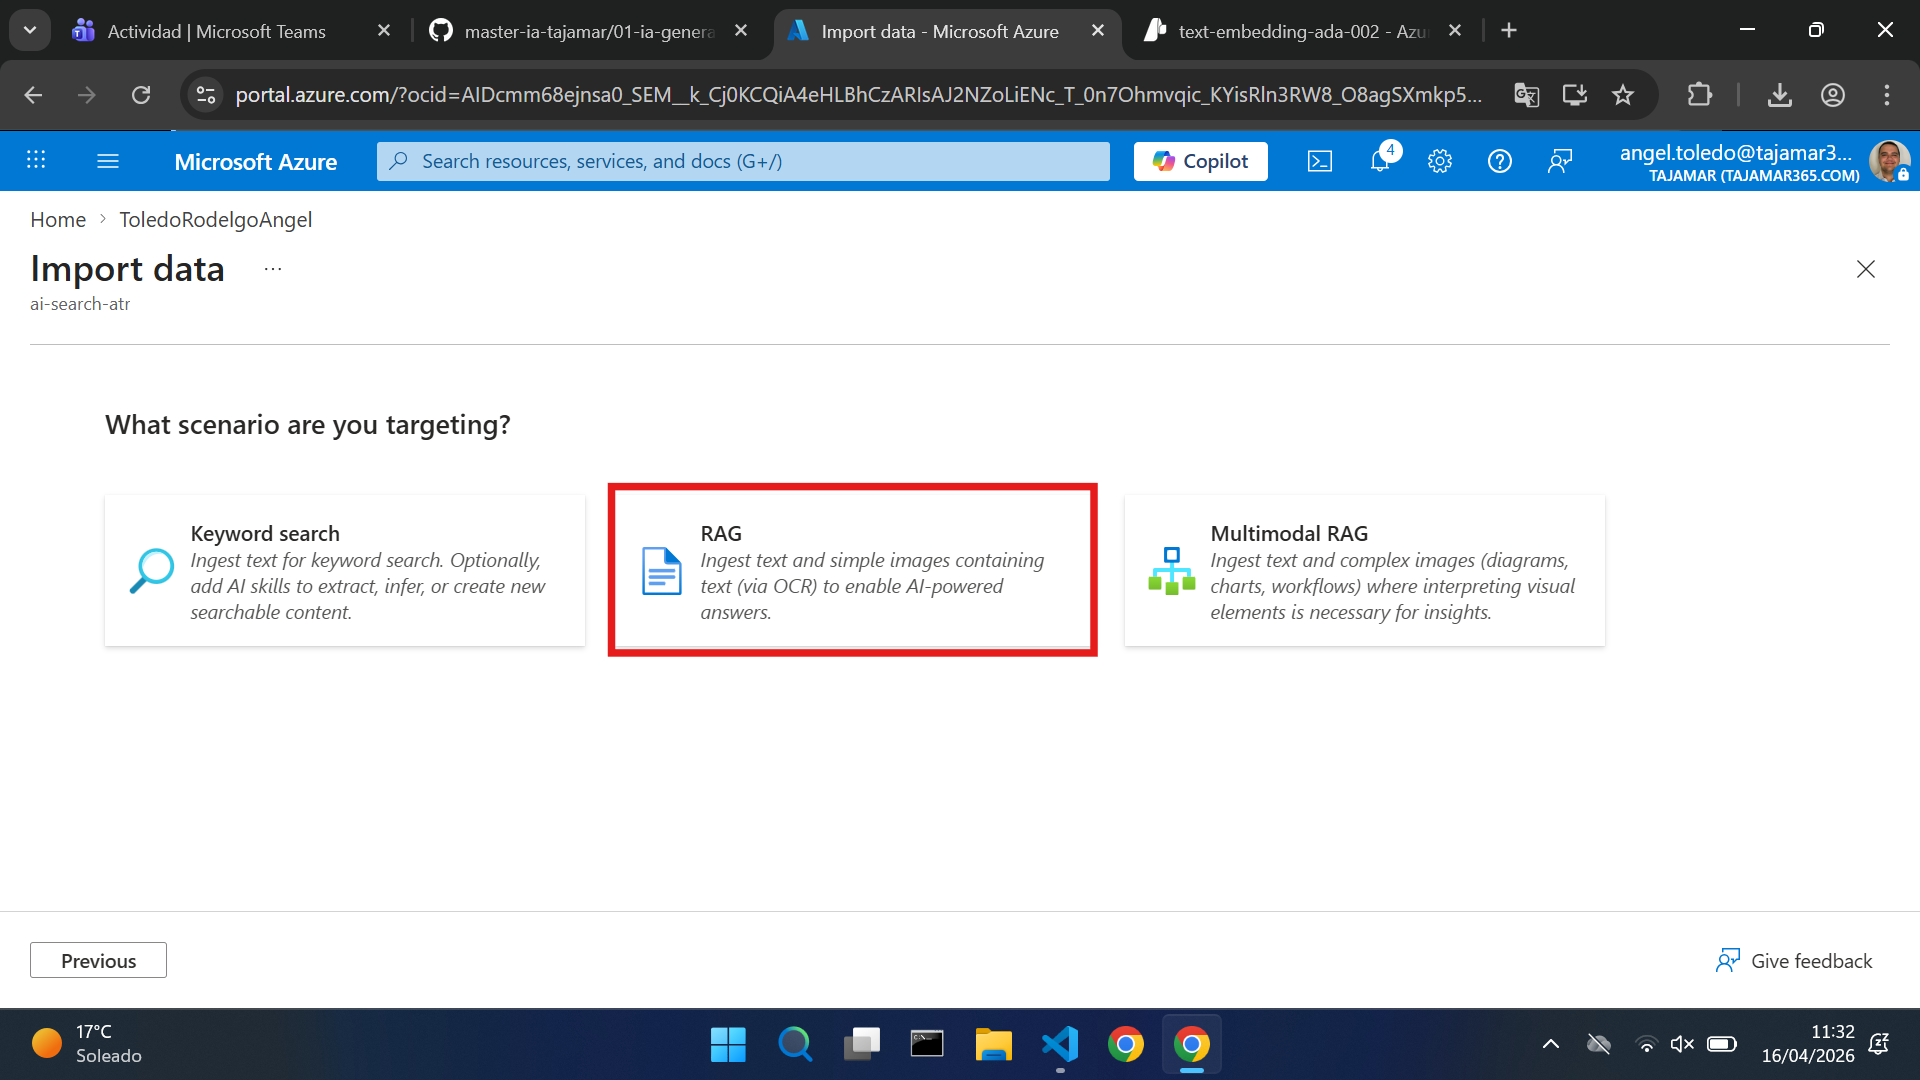

4. Seleccionamos nuestro almacenamiento para conectarlo a Azure AI Search.
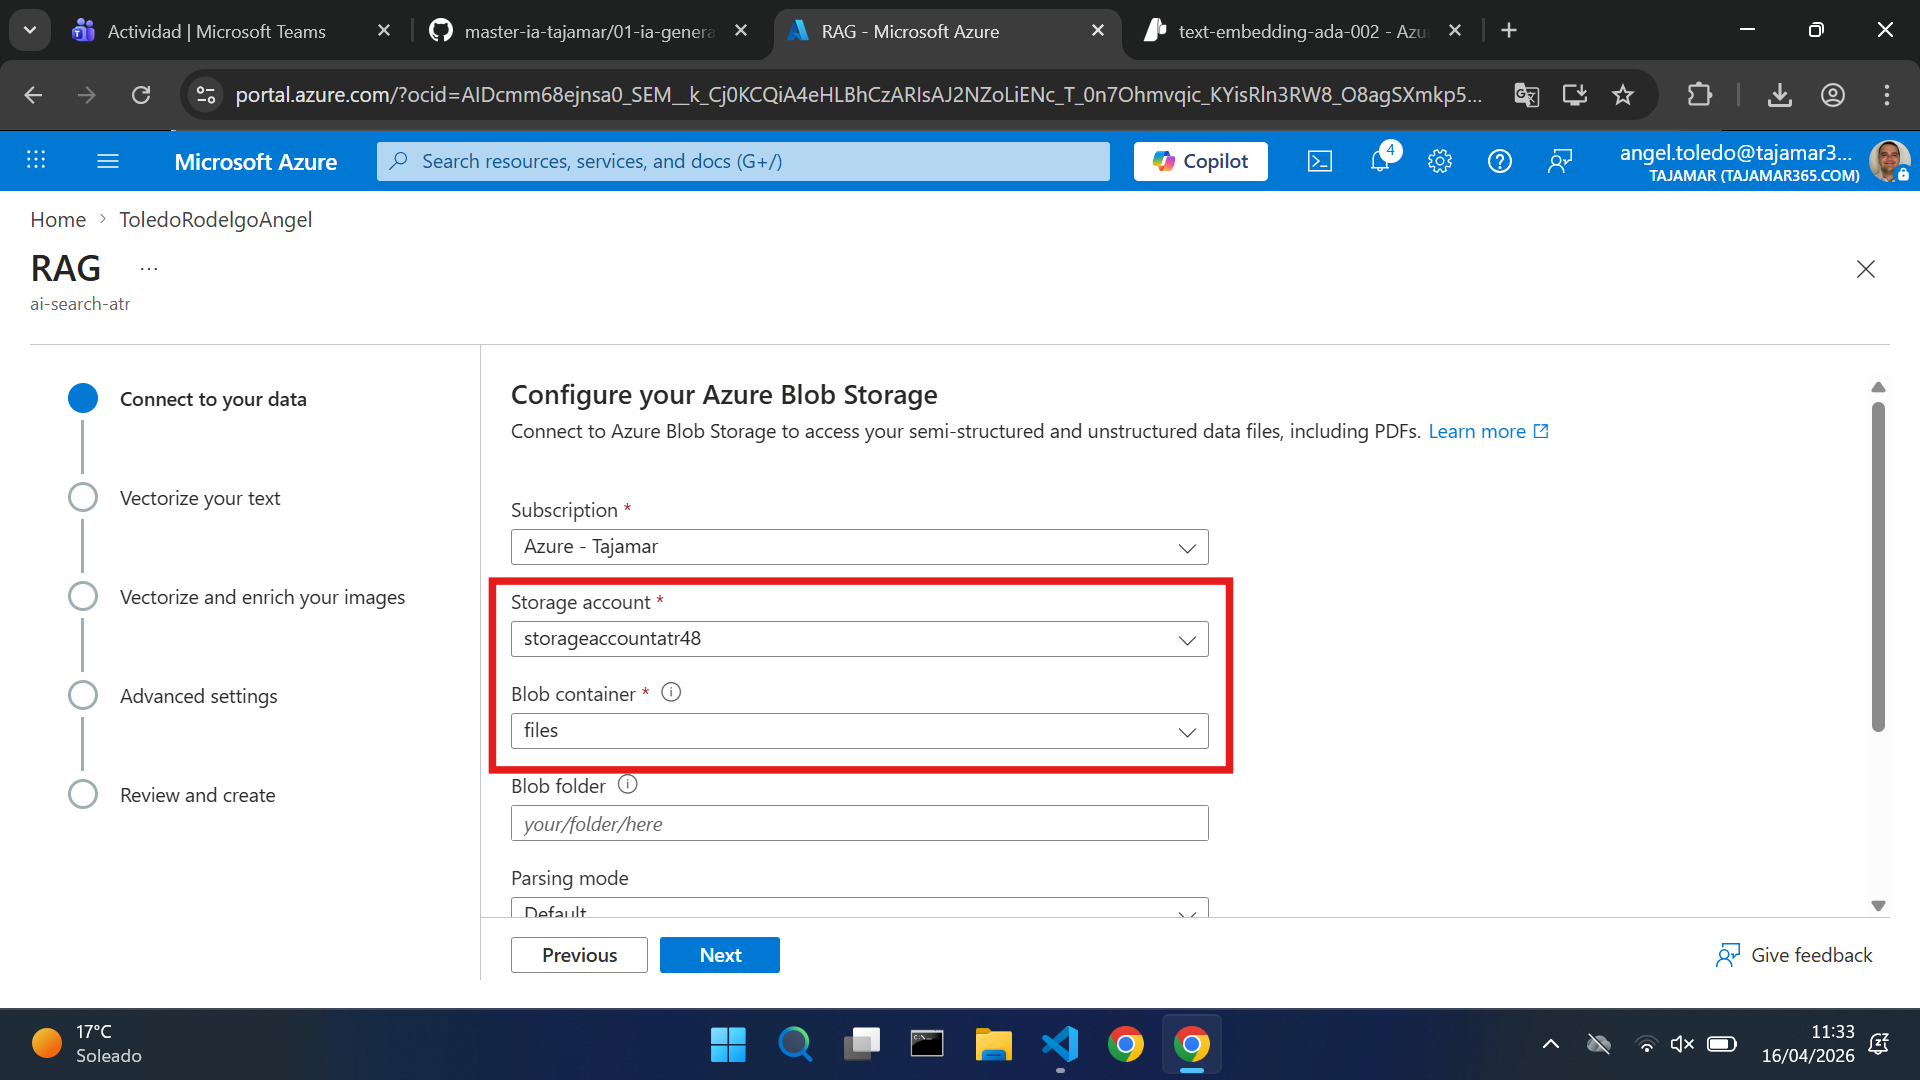

5. Elegimos el proveedor de nuestro deployment de Embeddings y lo seleccionamos.
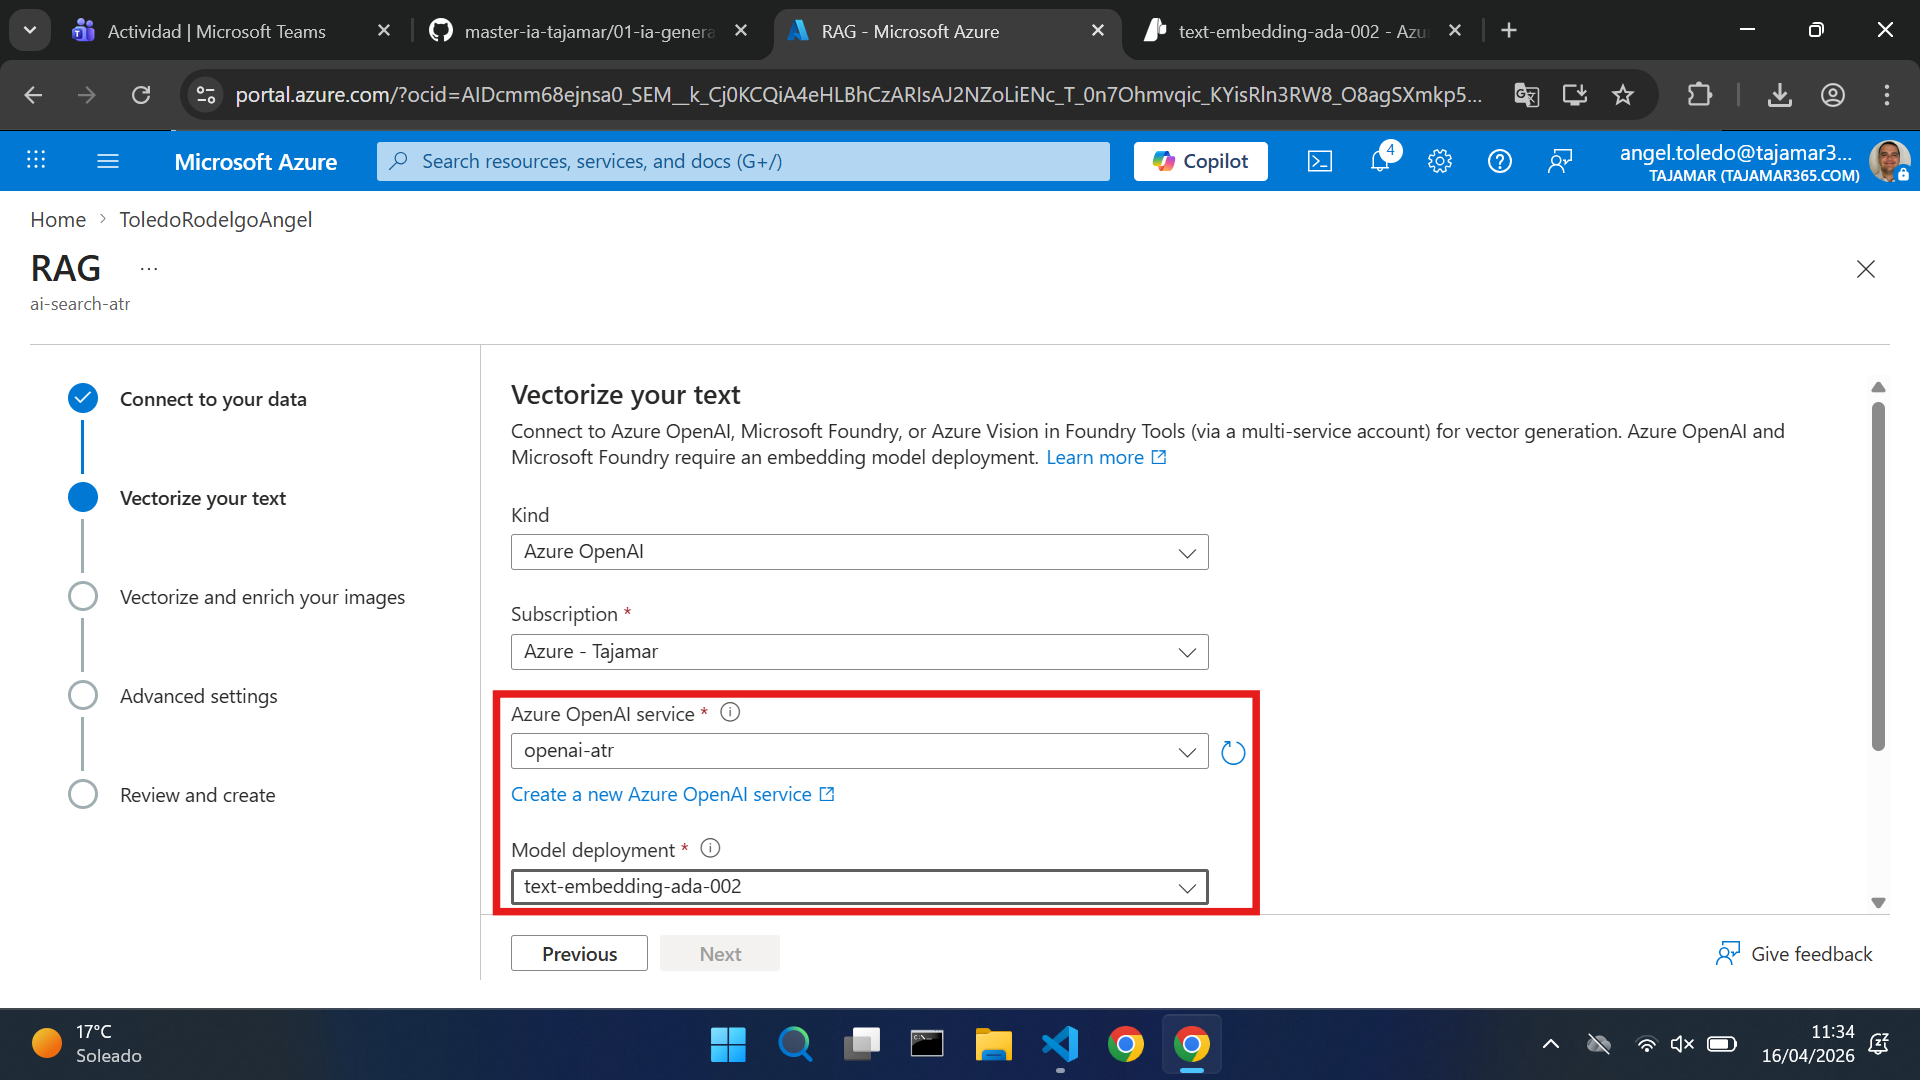

6. Seleccionamos el check-box de "Extract text from images" y conectamos el Cognitive Services que tiene que estar en la misma región que el AI Search.
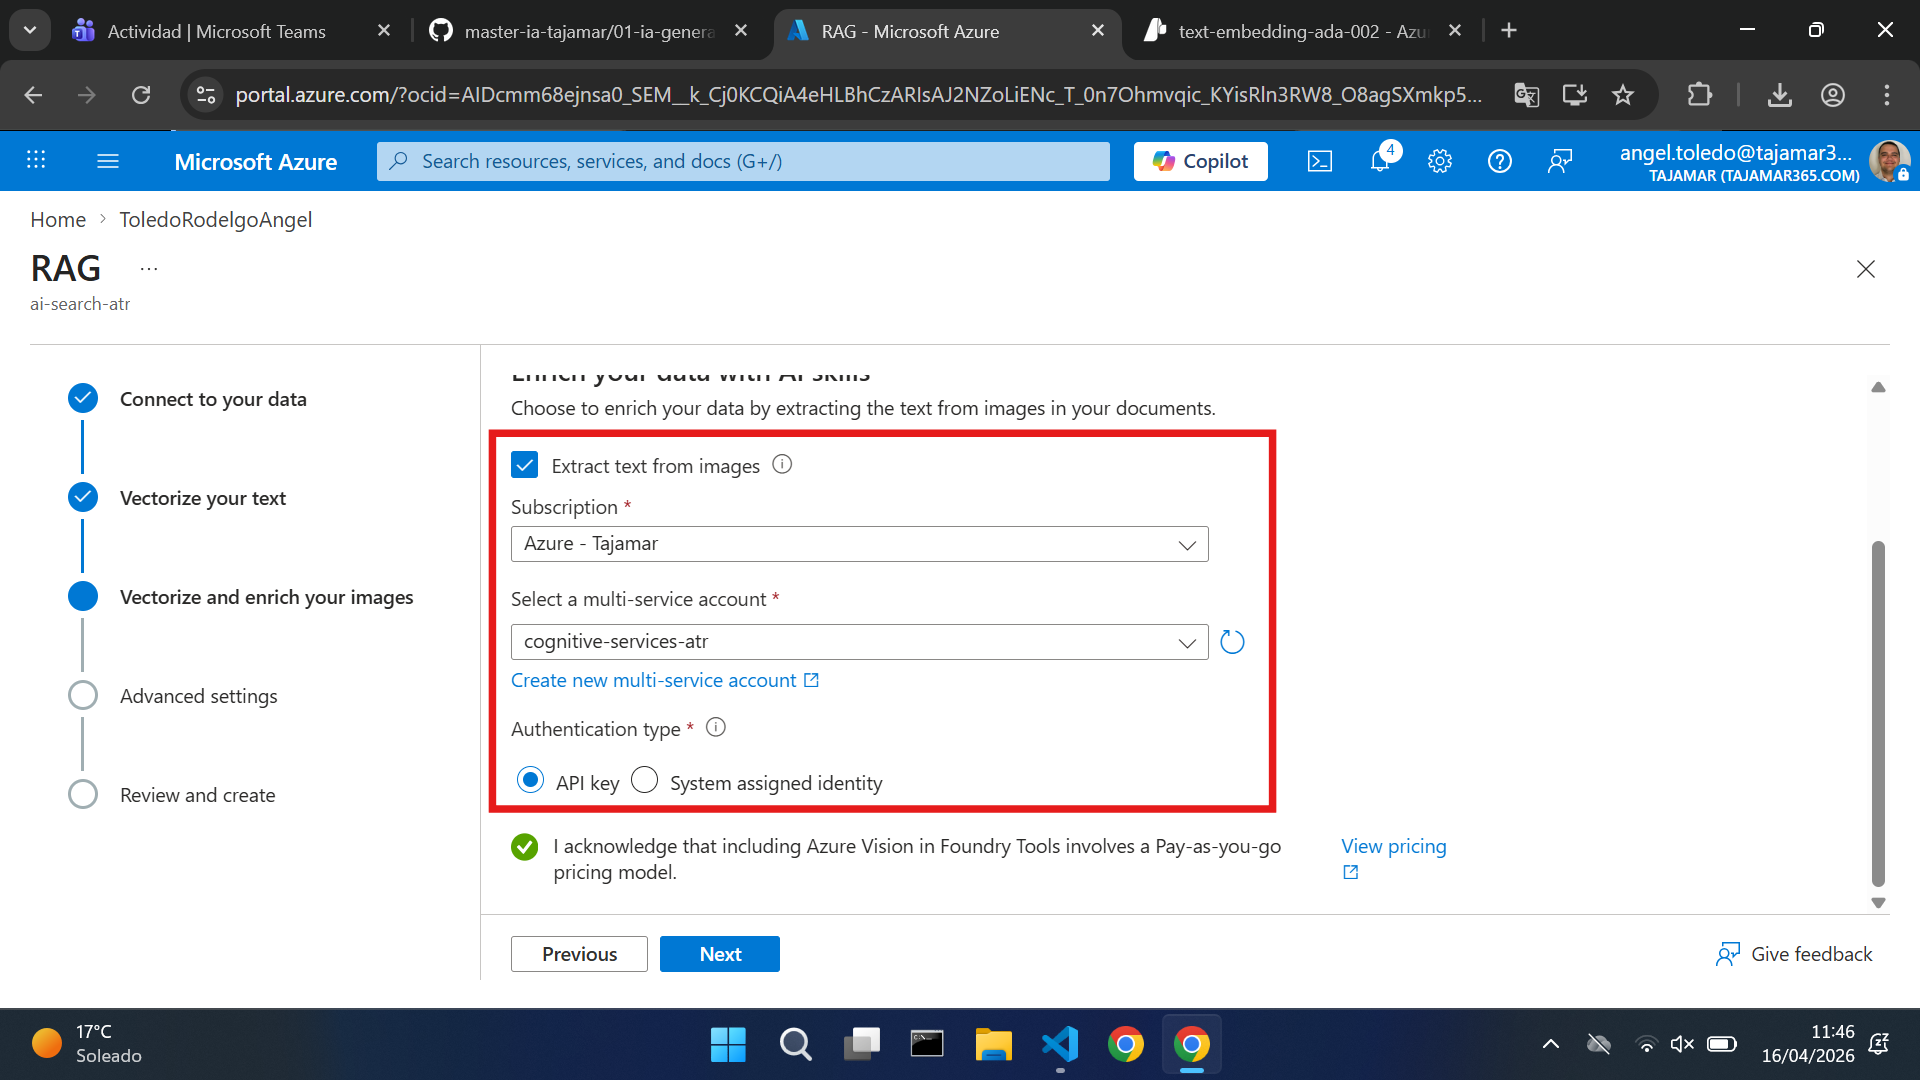

7. Revisamos la inferencia del esquema para comprobar que está correcta.
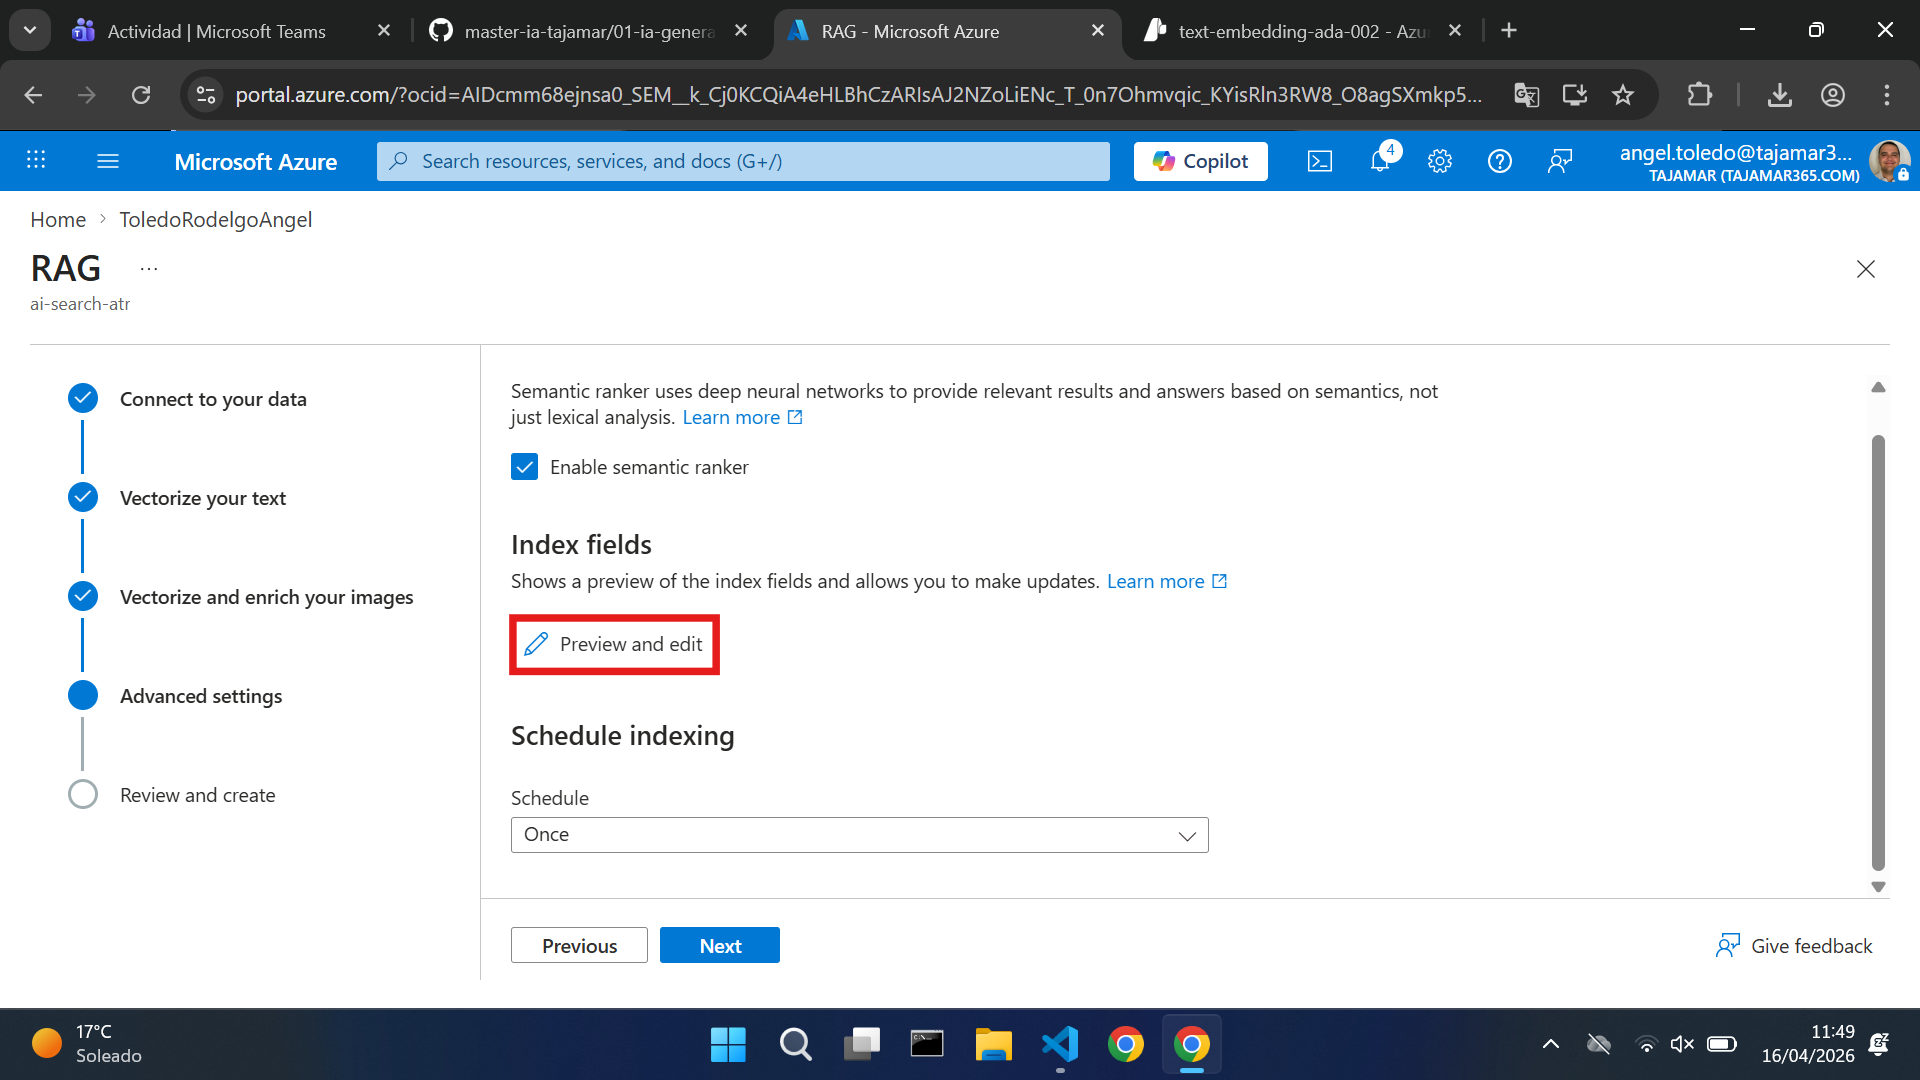
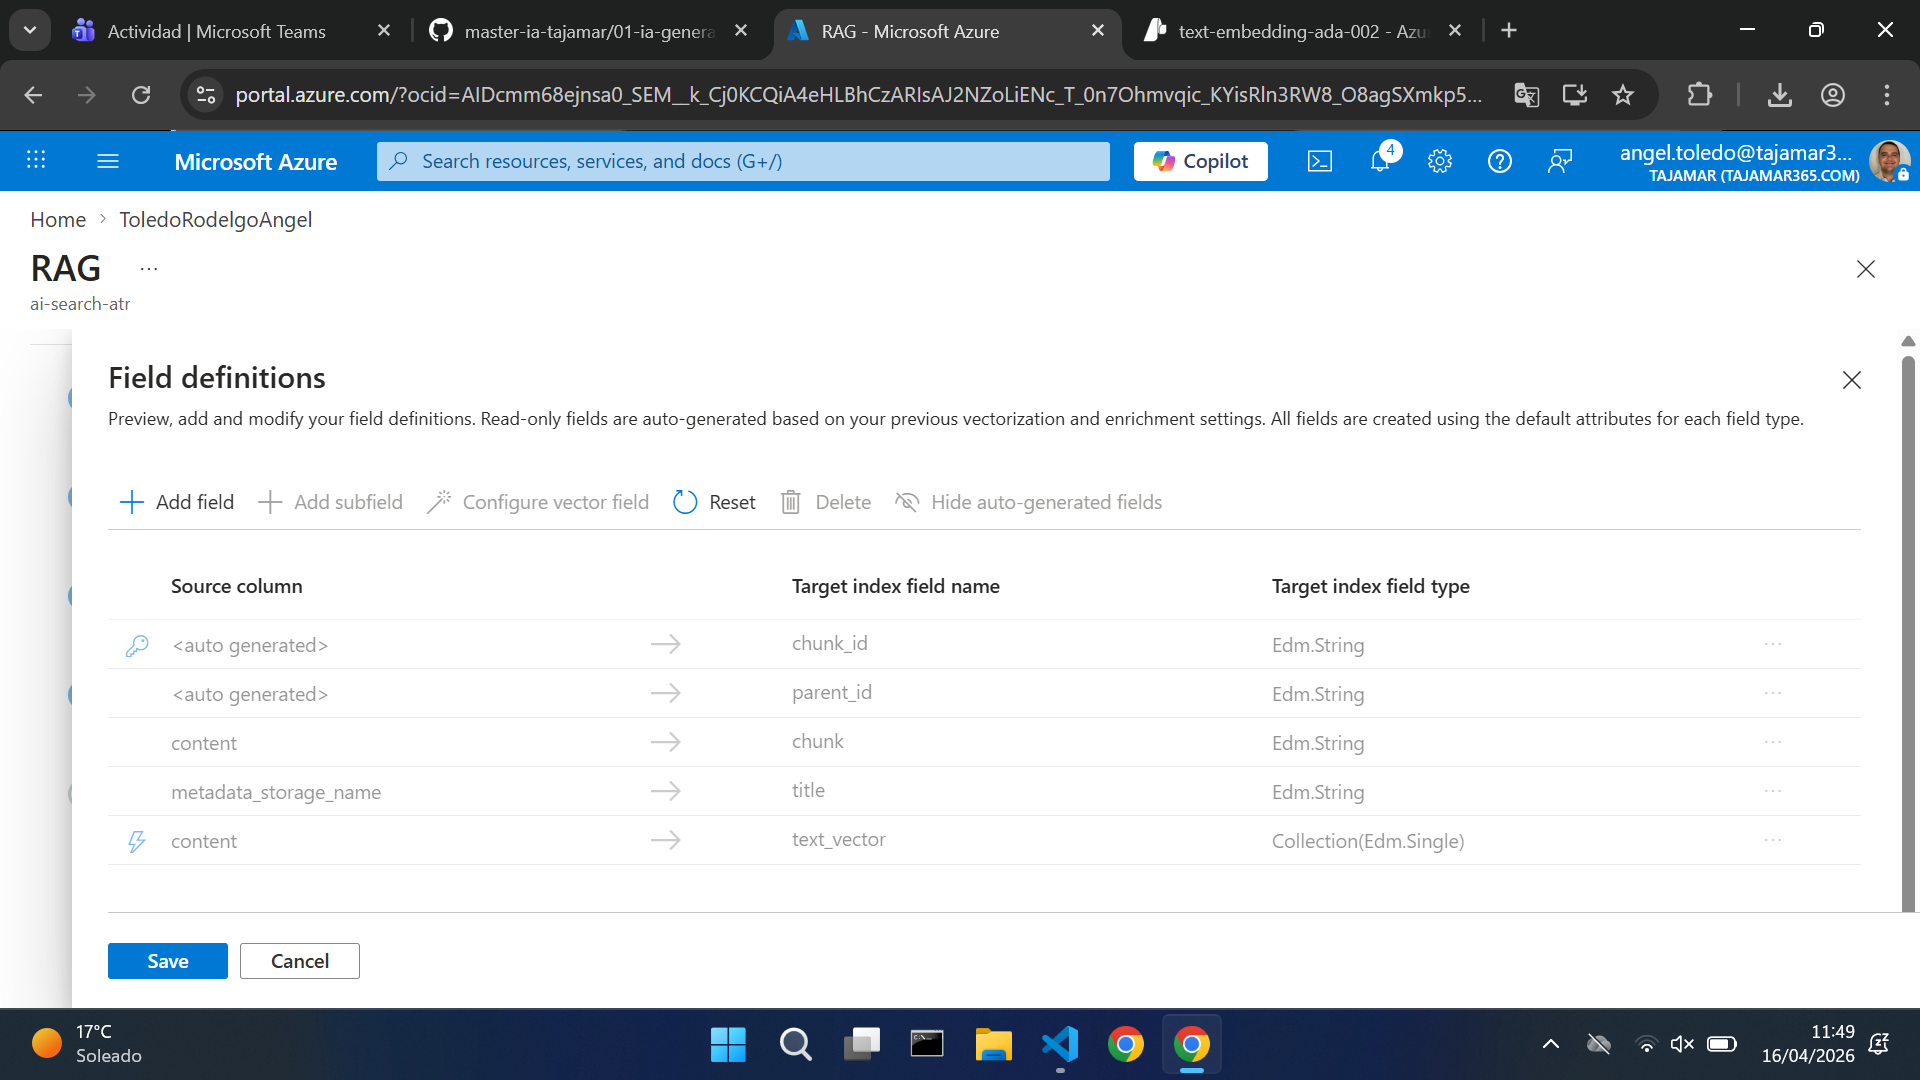

8. Seleccionamos crear y el wizard creará el Data Source, Index, Skillset (porque hemos activado el enrichment), Indexer y Knowledge Store opcional.
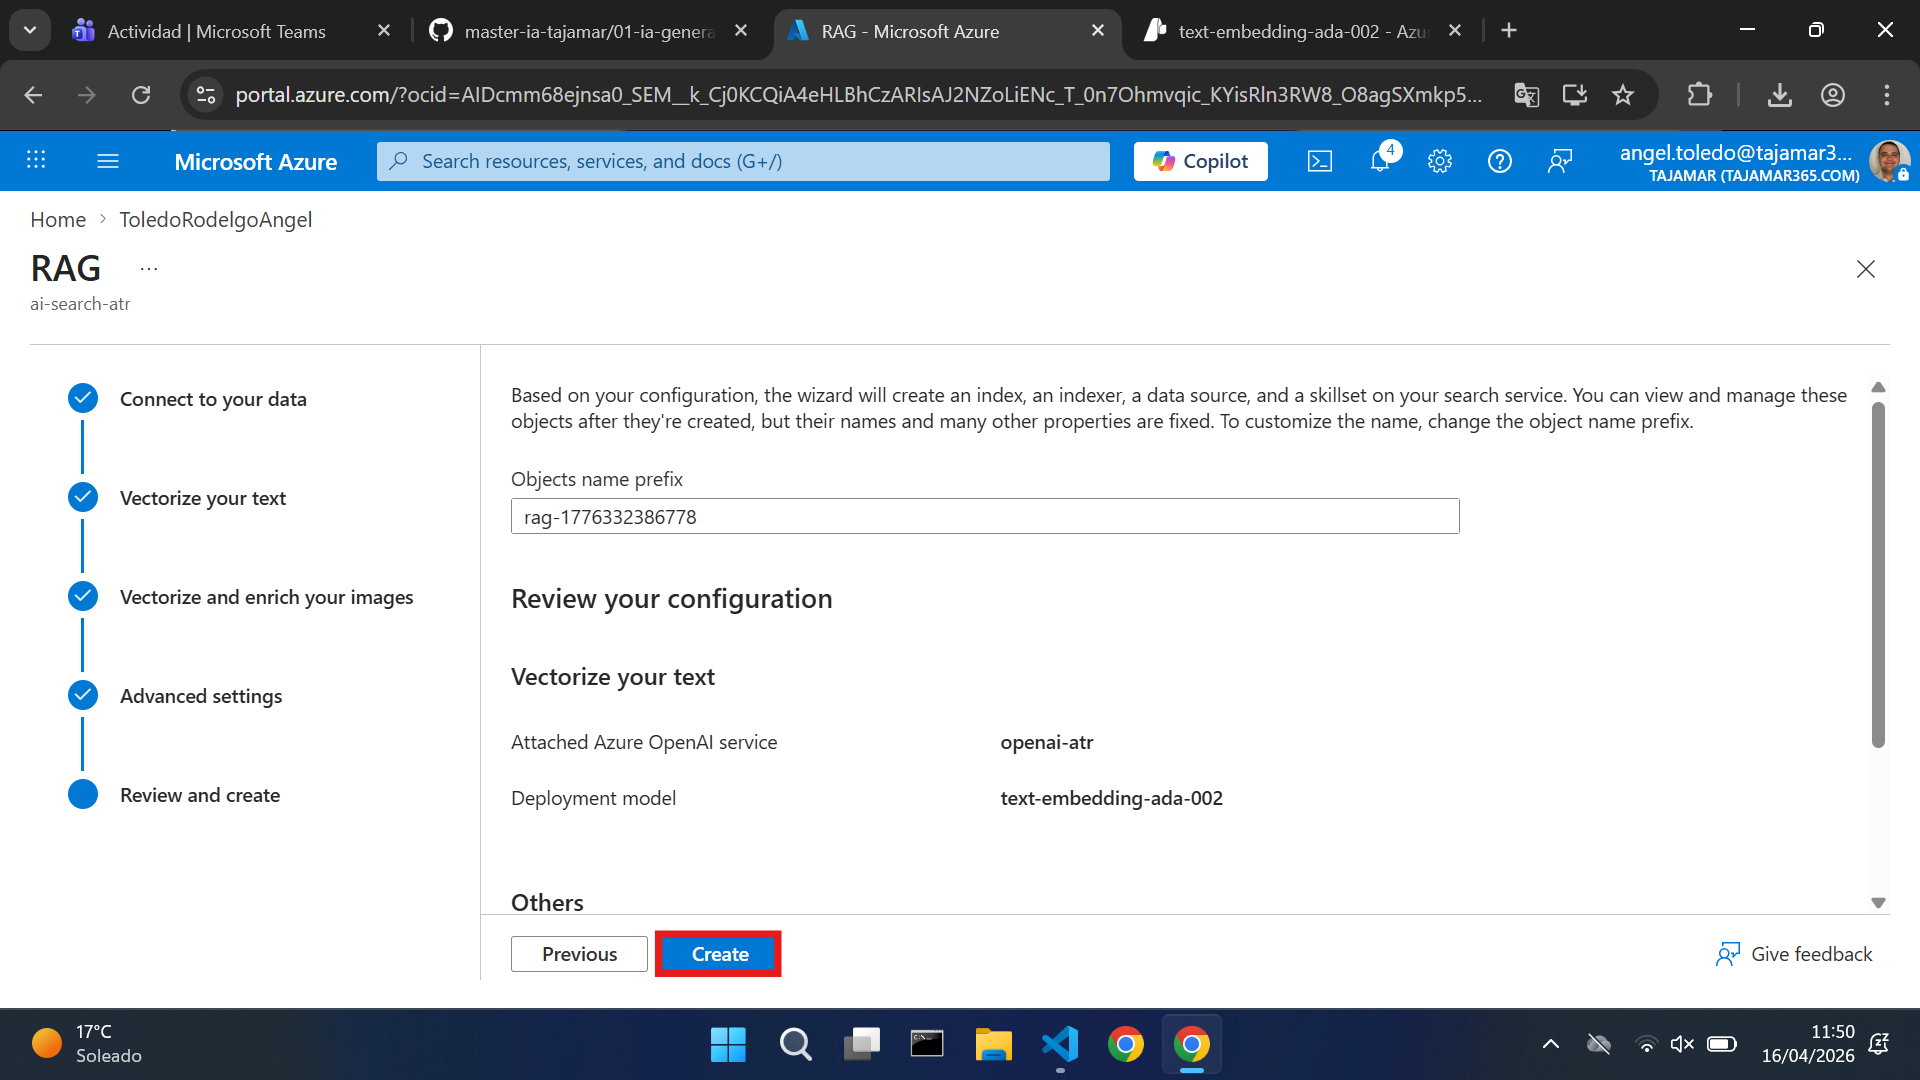

## Explicaciones al respecto

### Index (Index schema)

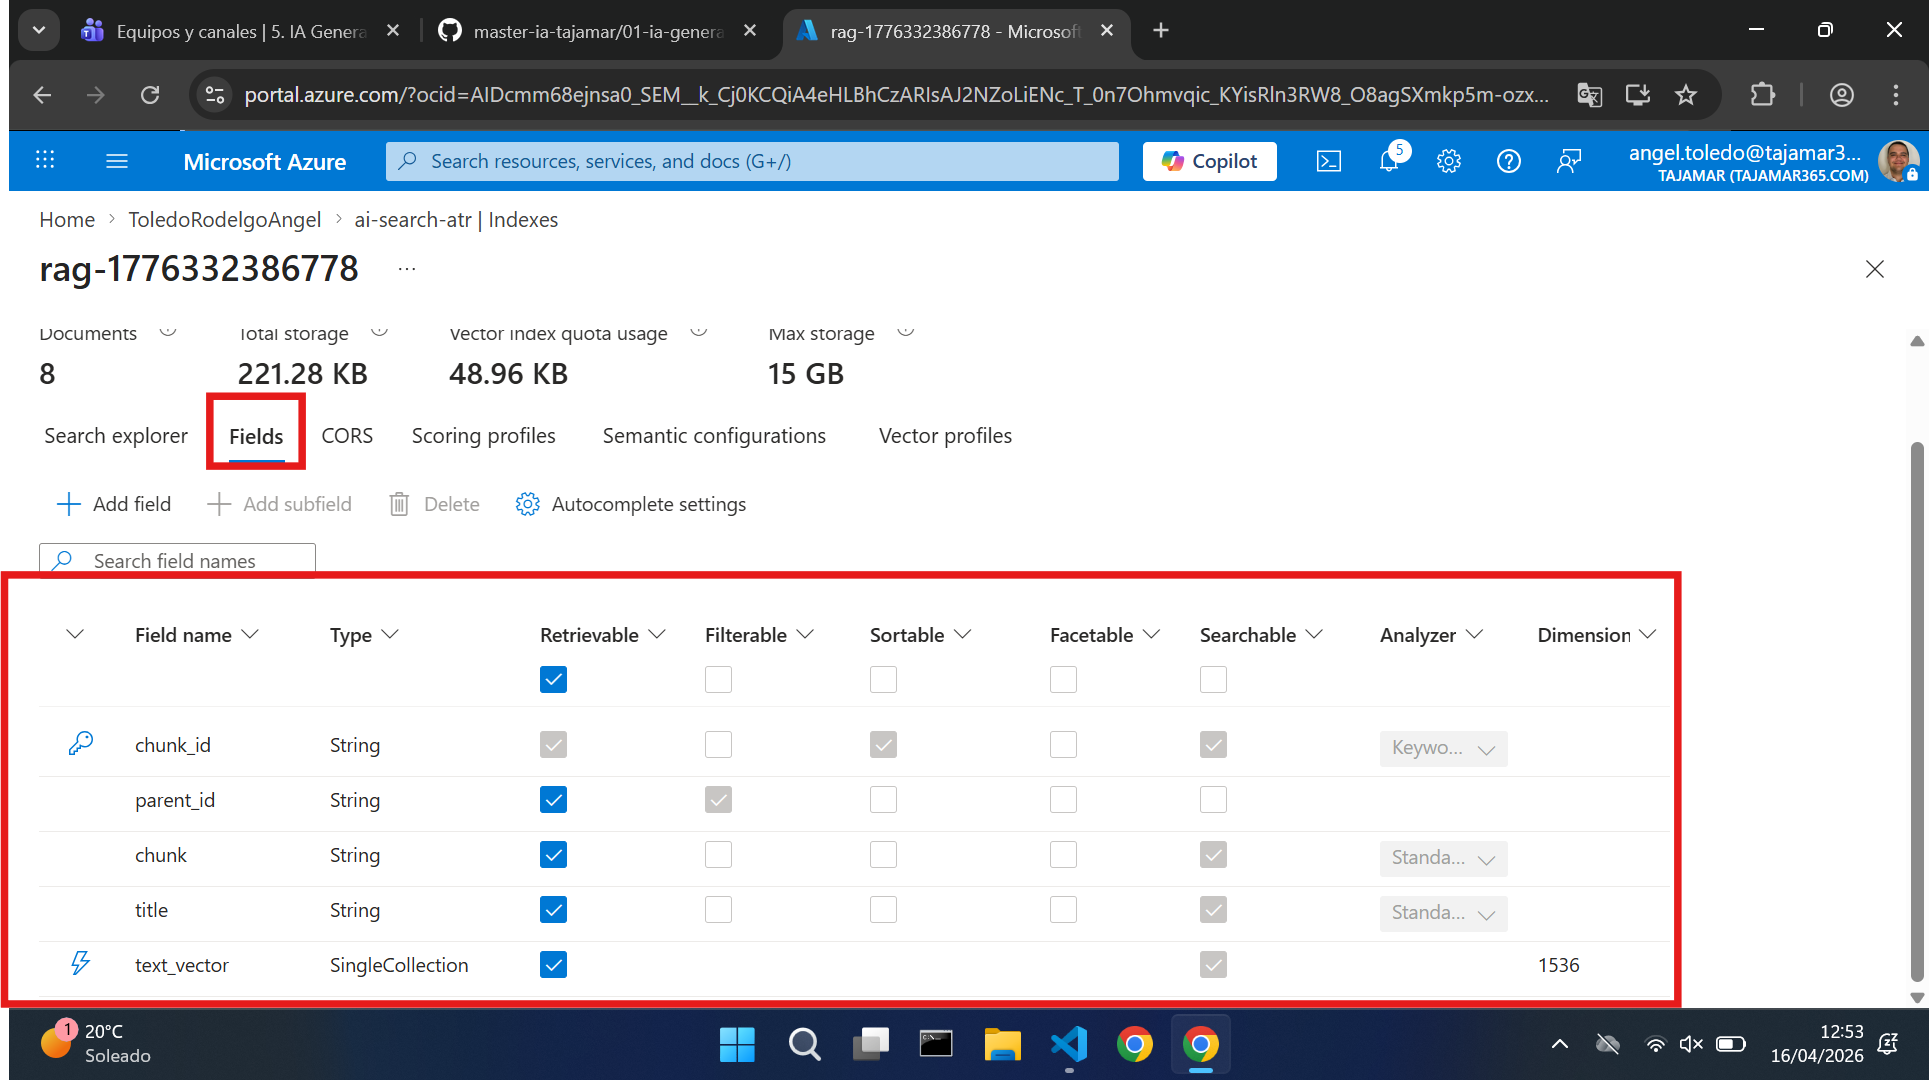

Si accedemos al índice que hemos creado, podremos ver su esquema en la pestaña "Fields".

### Semantic Configuration

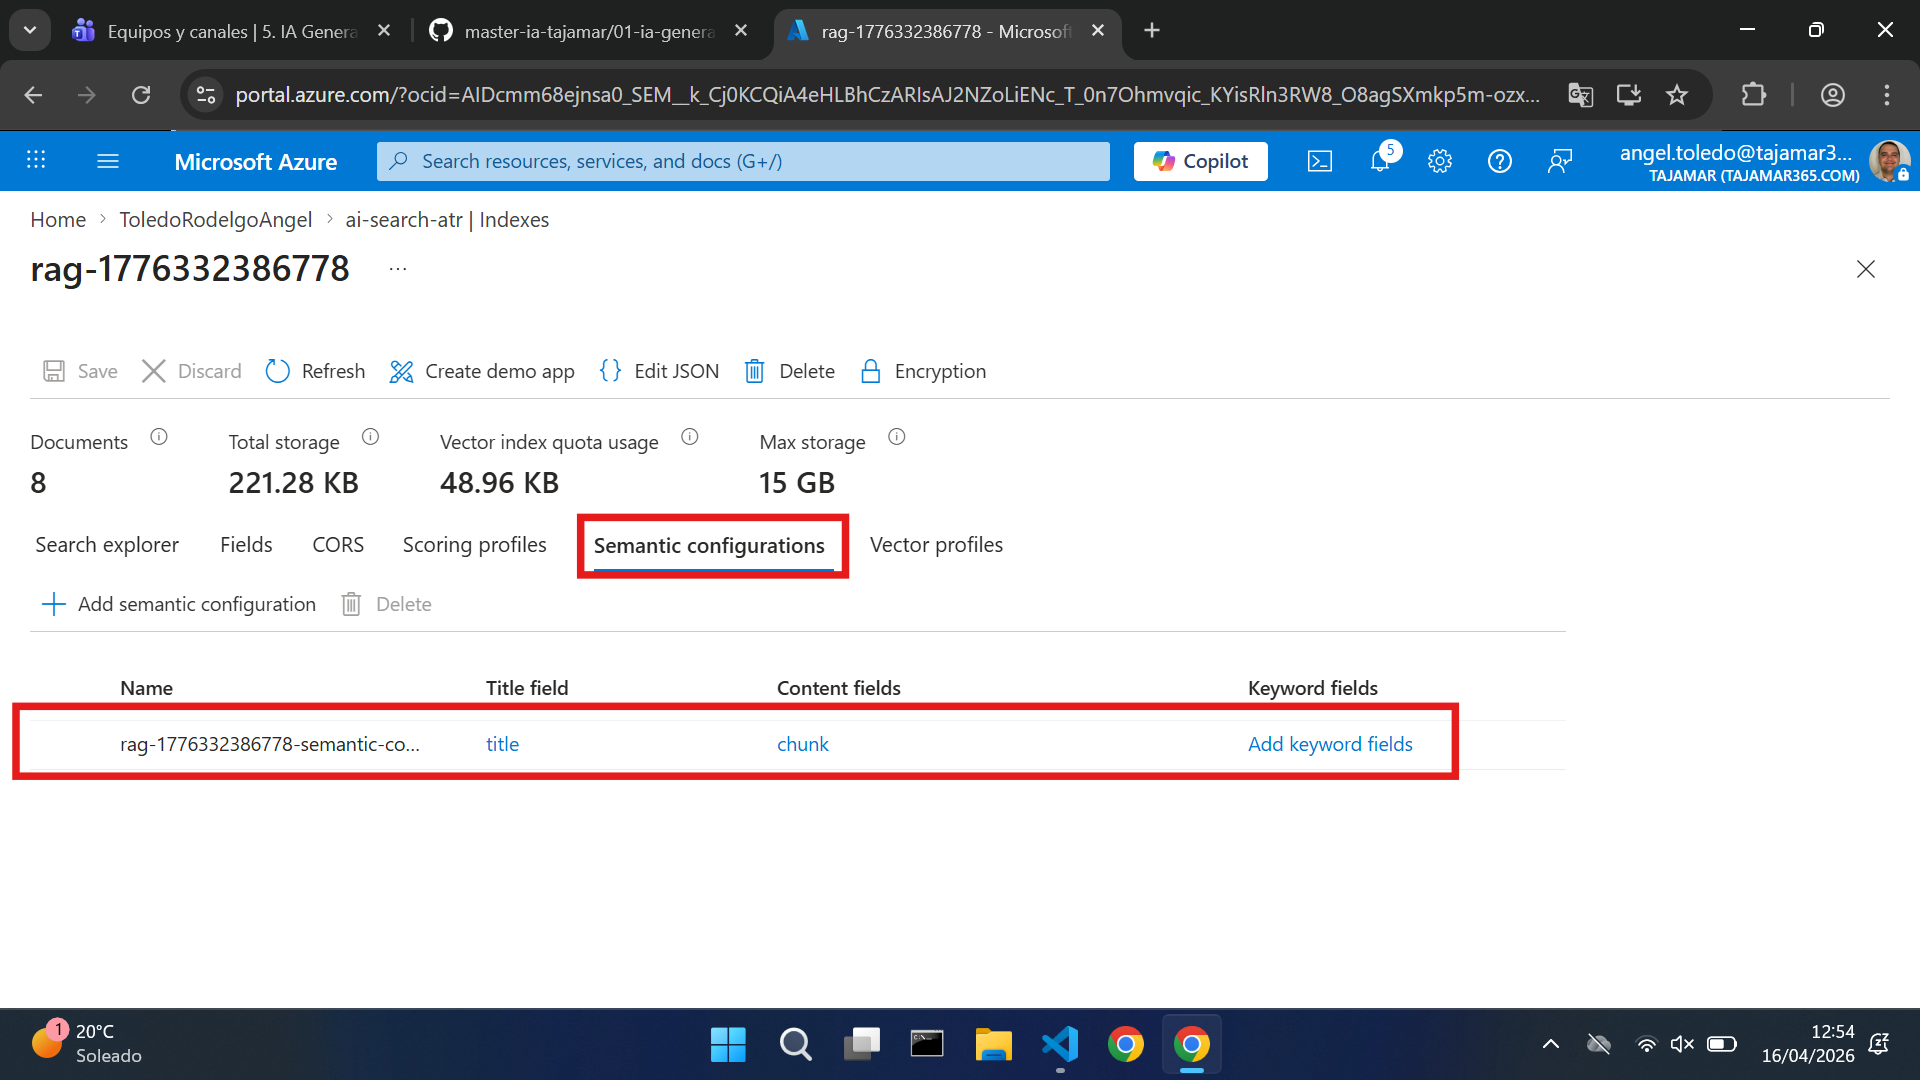

**¿Qué es una Configuración Semántica y cómo funciona?**

Es una funcionalidad avanzada de Azure que actúa como un segundo filtro inteligente.

Funcionamiento:
1. Un usuario hace una pregunta
2. El sistema recupera los fragmentos más relevantes mediante vectores o palabras clave
3. Esta configuración semántica utiliza:
    - Modelos de lenguaje natural de Microsoft para leer esos resultados iniciales
    - Comprender la intención real de la pregunta
    - Reordenar los resultados para poner los más exactos en primer lugar. 
    - Es capaz de extraer "subtítulos" o respuestas directas del texto.

**Configuración**

- Title Field: Asignado al campo title del Index Schema, indicando el título del documento. 
- Content Fields: Asignado al campo chunk del Index Schema, indicando que ahí está la información en crudo donde tiene que buscar.

### Vector Profile

#### Vector Algorithm

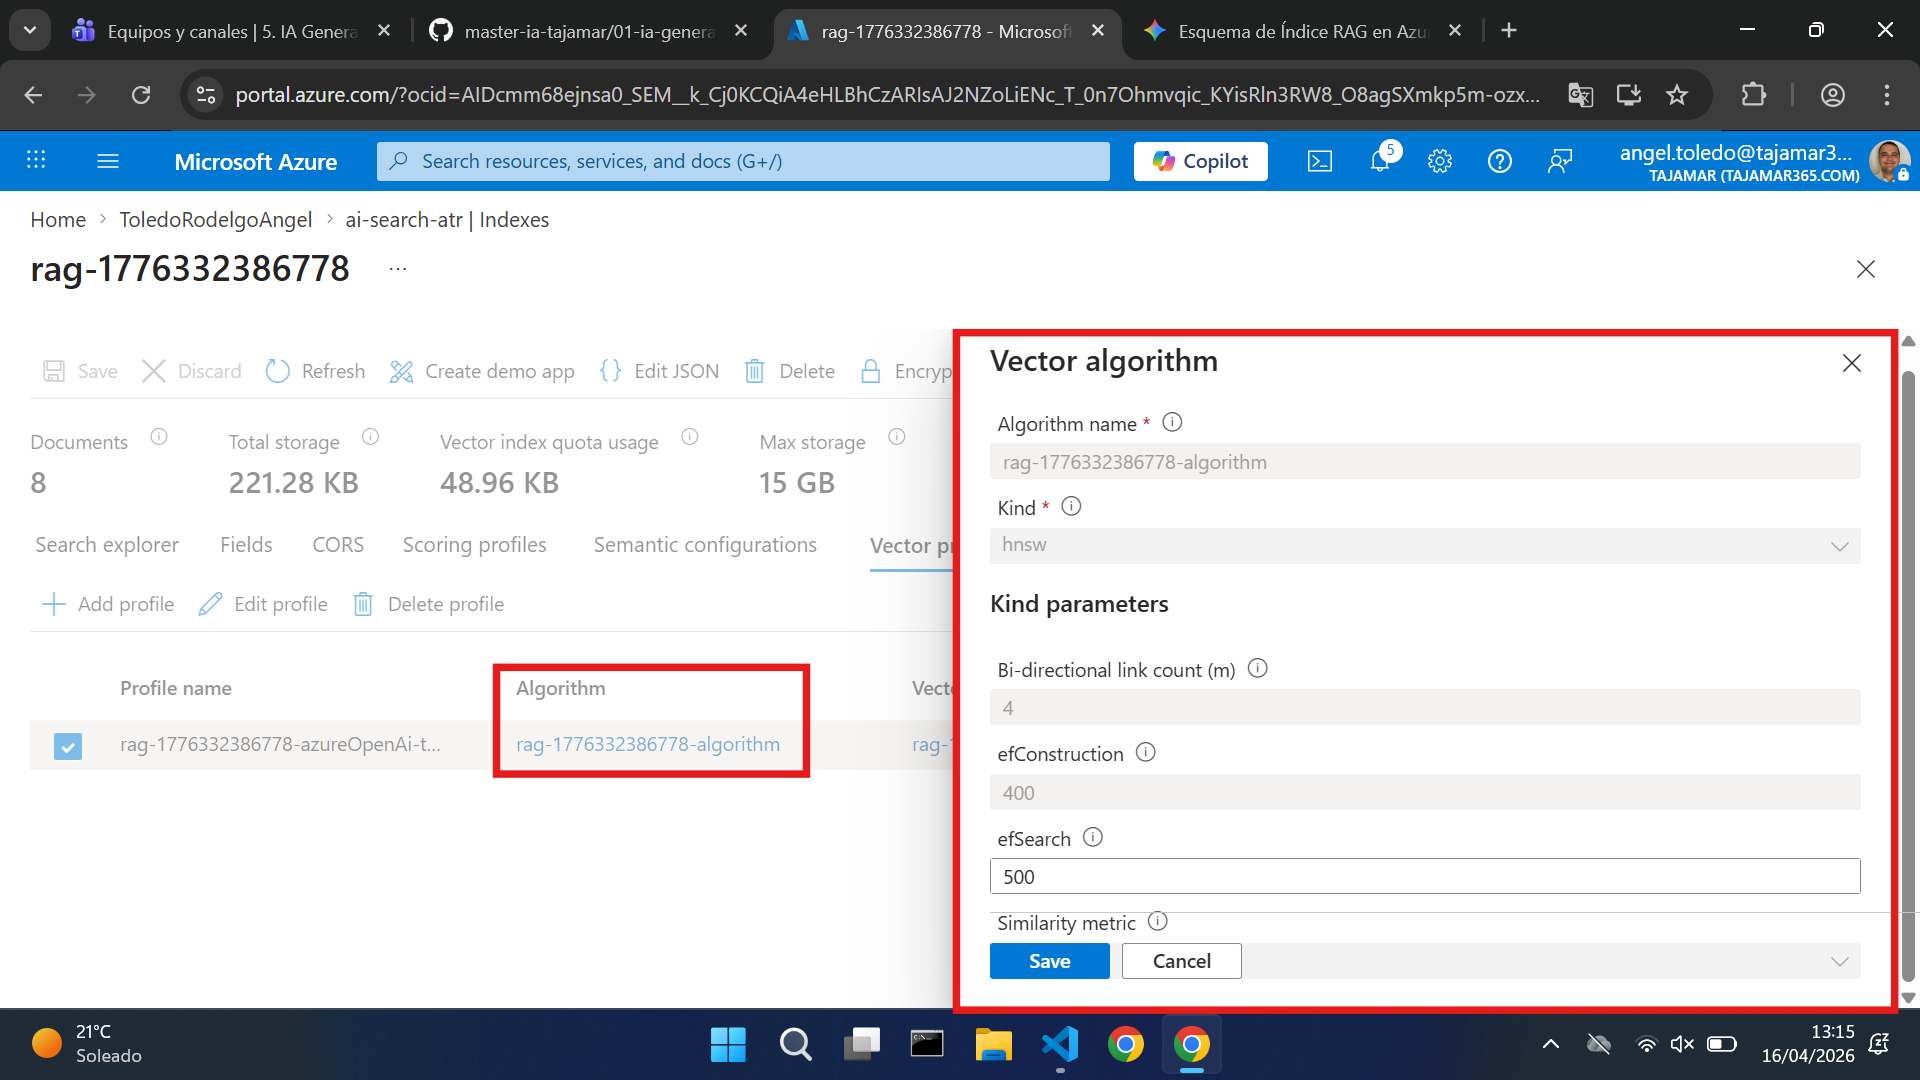

**¿Qué es Vector Algorithm?**

Es el motor de búsqueda para encontrar los resultados más parecidos a la pregunta del usuario.

**Configuración**

- Kind: Es el tipo de algoritmo, por defecto viene hnsw (Hierarchical Navigable Small World). Es el estándar para búsquedas vectoriales a gran escala. Construye un sistema de redes en múltiples capas lo que le permite encontrar los "vecinos más cercanos" a una velocidad muy alta.

- Bi-directional link count (m): Define el número máximo de conexiones que tiene cada nodo (documento, imágen...) dentro de esa red. En nuestro caso, un valor de 4 es suficiente ya que mantiene el índice ligero y ahorra memoria RAM. En bases de datos gigantes este valor se sube a 16 o 32 para mejorar la interconexión.

- efConstruction: Controla el esfuerzo que hace la máquina al ingestar los documentos para construir el índice. Un valor de 400 es alto, lo que asegura que el mapa mental que se crea sea de alta calidad al consumir más recursos y tiempo.

- efSearch: Controla el esfuerzo de la máquina cuando el usuario hace una pregunta. El valor define cuántos nodos candidatos se exploran antes de devolver la respuesta, por lo que un valor de 500 también es alto, aumentando la precisión de los resultados obtenidos.

#### Vectorizer

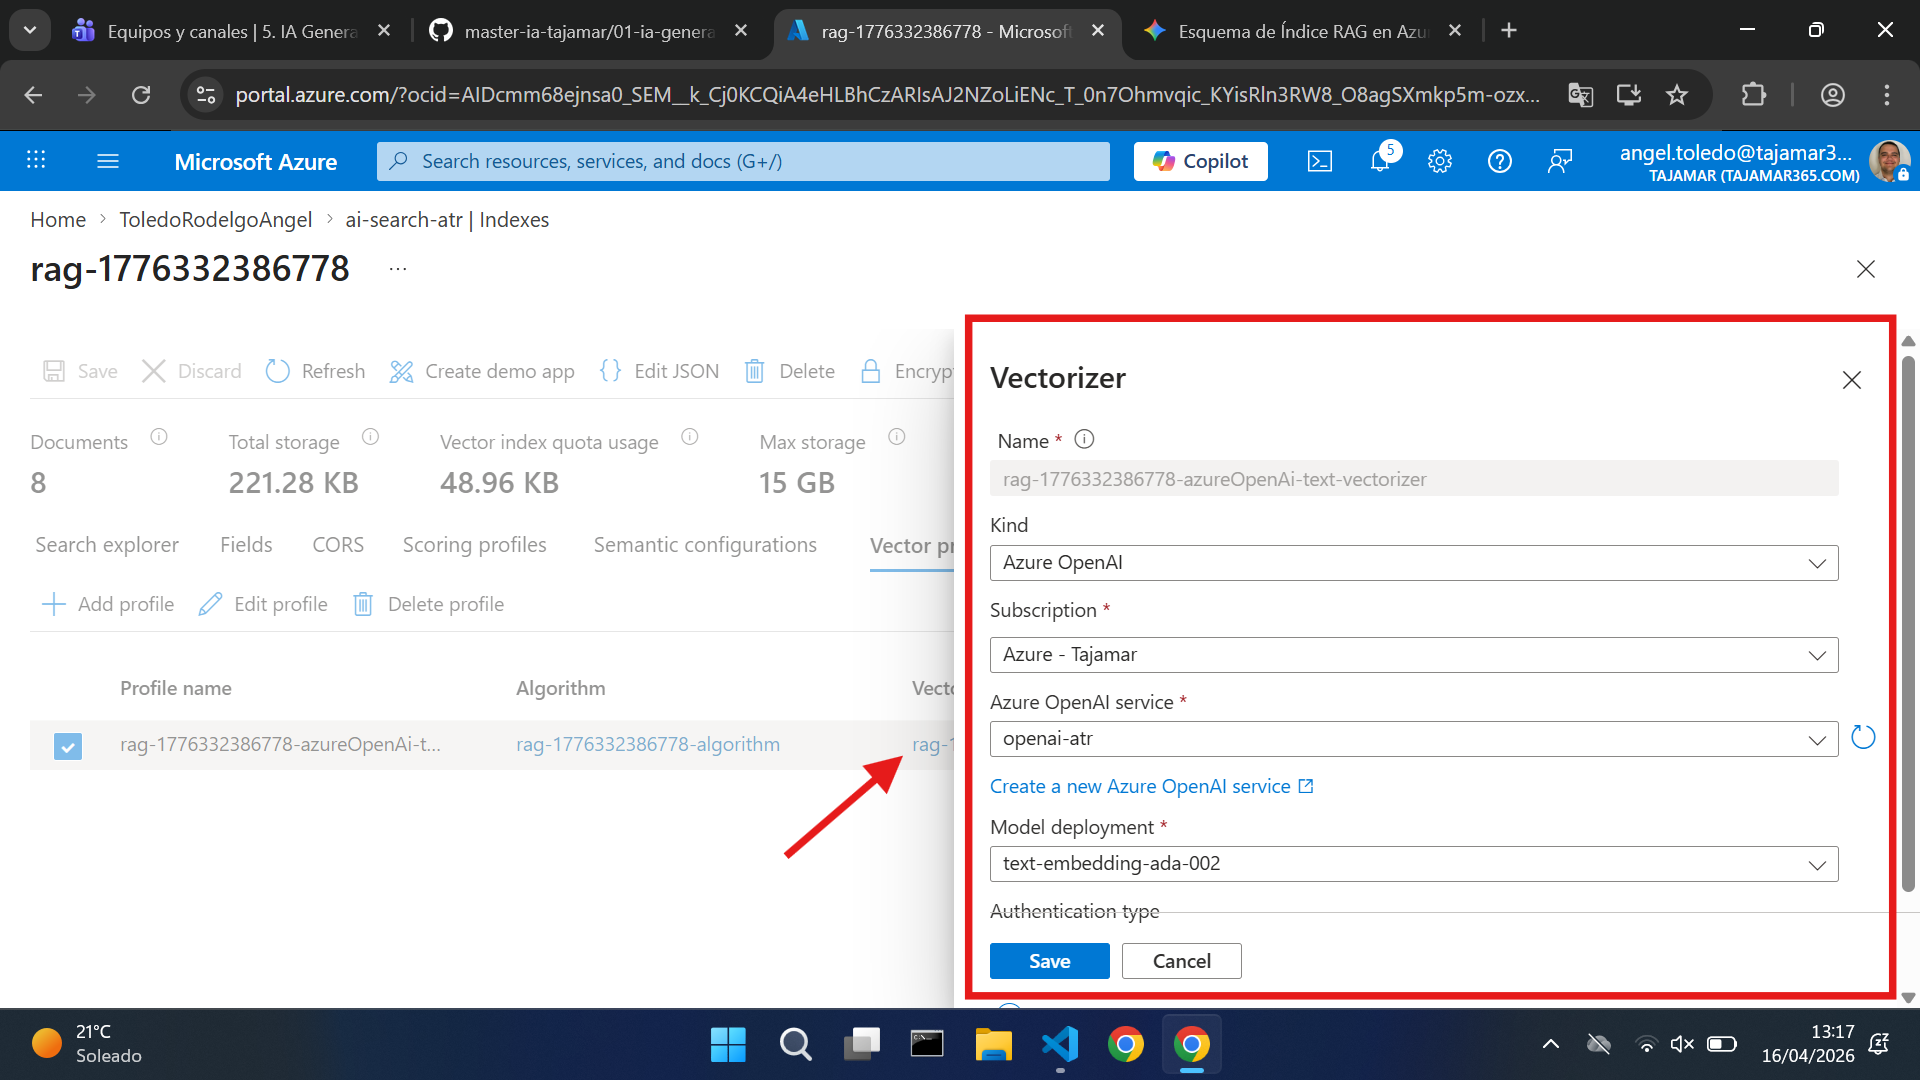

**¿Qué es el Vectorizer?**

Es el modelo de embedding que vamos a usar para vectorizar la query y poder buscar directamente en la BBDD vectorial.

**Configuración**

- Kind: Es el tipo de servicio que se usa para alojar el modelo de embedding. (Azure OpenAI/Foundry)

- Azure OpenAI service: Es el recurso específico de OpenAI que hemos creado para que reciba las peticiones. (openai-atr)

- Model deployment: Es el modelo de embedding específico de OpenAI que hemos desplegado para crear los vectores. (text-embedding-ada-002)

### Skillset

<div style="max-height: 400px; overflow-y: auto; overscroll-behavior: contain; background-color: #ffffff; border: 1px solid #d0d7de; padding: 15px; border-radius: 6px;">

```json
{
  "@odata.etag": "\"0x8DE9BAE7AC67281\"",
  "name": "rag-1776332386778-skillset",
  "description": "Skillset to chunk documents and generate embeddings",
  "skills": [
    {
      "@odata.type": "#Microsoft.Skills.Vision.OcrSkill",
      "name": "#1",
      "context": "/document/normalized_images/*",
      "lineEnding": "Space",
      "defaultLanguageCode": "en",
      "detectOrientation": true,
      "inputs": [
        {
          "name": "image",
          "source": "/document/normalized_images/*",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "text",
          "targetName": "text"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.MergeSkill",
      "name": "#2",
      "context": "/document",
      "insertPreTag": " ",
      "insertPostTag": " ",
      "inputs": [
        {
          "name": "text",
          "source": "/document/content",
          "inputs": []
        },
        {
          "name": "itemsToInsert",
          "source": "/document/normalized_images/*/text",
          "inputs": []
        },
        {
          "name": "offsets",
          "source": "/document/normalized_images/*/contentOffset",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "mergedText",
          "targetName": "mergedText"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.SplitSkill",
      "name": "#3",
      "description": "Split skill to chunk documents",
      "context": "/document",
      "defaultLanguageCode": "en",
      "textSplitMode": "pages",
      "maximumPageLength": 2000,
      "pageOverlapLength": 500,
      "maximumPagesToTake": 0,
      "unit": "characters",
      "inputs": [
        {
          "name": "text",
          "source": "/document/mergedText",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "textItems",
          "targetName": "pages"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.AzureOpenAIEmbeddingSkill",
      "name": "#4",
      "context": "/document/pages/*",
      "resourceUri": "https://openai-atr.openai.azure.com",
      "apiKey": "<redacted>",
      "deploymentId": "text-embedding-ada-002",
      "dimensions": 1536,
      "modelName": "text-embedding-ada-002",
      "inputs": [
        {
          "name": "text",
          "source": "/document/pages/*",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "embedding",
          "targetName": "text_vector"
        }
      ]
    }
  ],
  "cognitiveServices": {
    "@odata.type": "#Microsoft.Azure.Search.AIServicesByKey",
    "key": "<redacted>",
    "subdomainUrl": "https://cognitive-services-atr.cognitiveservices.azure.com/"
  },
  "indexProjections": {
    "selectors": [
      {
        "targetIndexName": "rag-1776332386778",
        "parentKeyFieldName": "parent_id",
        "sourceContext": "/document/pages/*",
        "mappings": [
          {
            "name": "text_vector",
            "source": "/document/pages/*/text_vector",
            "inputs": []
          },
          {
            "name": "chunk",
            "source": "/document/pages/*",
            "inputs": []
          },
          {
            "name": "title",
            "source": "/document/title",
            "inputs": []
          }
        ]
      }
    ],
    "parameters": {
      "projectionMode": "skipIndexingParentDocuments"
    }
  }
}

**¿Qué es un Skillset?**

Es un pipeline o una secuencia de operaciones que preparan la información del documento para su posterior indexado

**Configuración**

1. OCRSkill: Escanea el documento en busca de imágenes integradas y extrae el texto con el OCR.
2. MergeSkill: Coge el texto principal del documento y le inserta el texto del paso anterior.
3. SplitSkill: Coge todo el texto unificado y lo corta en chunks.
4. AzureOpenAIEmbeddingSkill: Vectoriza el texto de la query para que funcione la búsqueda semántica.
5. AIServicesByKey: Una vez realizado todo el proceso, se produce el indexado de la información del documento en los campos correspondientes.

# 2. Búsquedas prácticas

In [20]:
from azure.core.credentials import AzureKeyCredential
from azure.search.documents import SearchClient
from azure.search.documents.models import VectorizableTextQuery

search_endpoint = "https://ai-search-atr.search.windows.net"
search_key = "QubzlhpKqbMmbwc8EVl7zYEazkNnY58Akr9HcO9s79AzSeD62dqy"
index_name = "rag-1776332386778"

search_client = SearchClient(search_endpoint, index_name, AzureKeyCredential(search_key))

In [26]:
user_query = "How to remove a directory?"

vector_query = VectorizableTextQuery(
    text=user_query,
    k_nearest_neighbors=5, 
    fields="text_vector"
)

## Vector Search

In [27]:
results_vector = search_client.search(
    search_text=None,
    vector_queries=[vector_query],
    select=["title", "chunk"]
)
for result in results_vector:
    print(f"📄 Documento: [{result['title']}] | Score: {result['@search.score']}")
    print(f"💬 Texto extraído: {result['chunk']}\n" + "-"*30)

📄 Documento: [bash-cheat-sheet.pdf] | Score: 0.81714725
💬 Texto extraído: Navigating the File System

cd [directory] Change directory

pwd Print working directory

ls [options] [directory] List directory contents

mkdir [directory] Create a new directory

rmdir [directory] Remove a directory

cp [source] [destination] Copy files or directories

mv [source] [destination] Move or rename files or directories

rm [options] [file] Remove files or directories

touch [file] Create an empty file

File Manipulation

cat [file] Output the contents of a file

head [options] [file] Output the first lines of a file

tail [options] [file] Output the last lines of a file

less [file] View the contents of a file interactively

grep [pattern] [file] Search for a pattern in a file

wc [options] [file] Count the number of lines, words, or characters in a file

Process Management

ps [options] Display information about active processes

kill [process_ID] Terminate a process

top Display and manage the top

## Hybrid Search

In [28]:
results_hybrid = search_client.search(
    search_text=user_query,
    vector_queries=[vector_query],
    select=["title", "chunk"]
)
for result in results_hybrid:
    print(f"📄 Documento: [{result['title']}] | Score: {result['@search.score']}")
    print(f"💬 Texto extraído: {result['chunk']}\n" + "-"*30)

📄 Documento: [bash-cheat-sheet.pdf] | Score: 0.03333333507180214
💬 Texto extraído: Navigating the File System

cd [directory] Change directory

pwd Print working directory

ls [options] [directory] List directory contents

mkdir [directory] Create a new directory

rmdir [directory] Remove a directory

cp [source] [destination] Copy files or directories

mv [source] [destination] Move or rename files or directories

rm [options] [file] Remove files or directories

touch [file] Create an empty file

File Manipulation

cat [file] Output the contents of a file

head [options] [file] Output the first lines of a file

tail [options] [file] Output the last lines of a file

less [file] View the contents of a file interactively

grep [pattern] [file] Search for a pattern in a file

wc [options] [file] Count the number of lines, words, or characters in a file

Process Management

ps [options] Display information about active processes

kill [process_ID] Terminate a process

top Display and manag

## Semantic Search

In [29]:
results_semantic = search_client.search(
    search_text=user_query,
    query_type="semantic",
    semantic_configuration_name="rag-1776332386778-semantic-configuration",
    select=["title", "chunk"]
)
for result in results_semantic:
    print(f"📄 Documento: [{result['title']}] | Reranker Score: {result['@search.reranker_score']}")
    print(f"💬 Texto extraído: {result['chunk']}\n" + "-"*30)

📄 Documento: [bash-cheat-sheet.pdf] | Reranker Score: 2.8535616397857666
💬 Texto extraído: Navigating the File System

cd [directory] Change directory

pwd Print working directory

ls [options] [directory] List directory contents

mkdir [directory] Create a new directory

rmdir [directory] Remove a directory

cp [source] [destination] Copy files or directories

mv [source] [destination] Move or rename files or directories

rm [options] [file] Remove files or directories

touch [file] Create an empty file

File Manipulation

cat [file] Output the contents of a file

head [options] [file] Output the first lines of a file

tail [options] [file] Output the last lines of a file

less [file] View the contents of a file interactively

grep [pattern] [file] Search for a pattern in a file

wc [options] [file] Count the number of lines, words, or characters in a file

Process Management

ps [options] Display information about active processes

kill [process_ID] Terminate a process

top Display a

## Semantic Hybrid Search

In [30]:
results_semantic_hybrid = search_client.search(
    search_text=user_query,
    vector_queries=[vector_query],
    query_type="semantic",
    semantic_configuration_name="rag-1776332386778-semantic-configuration",
    select=["title", "chunk"]
)
for result in results_semantic_hybrid:
    print(f"📄 Documento: [{result['title']}] | Reranker Score: {result['@search.reranker_score']}")
    print(f"💬 Texto extraído: {result['chunk']}\n" + "-"*30)

📄 Documento: [bash-cheat-sheet.pdf] | Reranker Score: 2.8535616397857666
💬 Texto extraído: Navigating the File System

cd [directory] Change directory

pwd Print working directory

ls [options] [directory] List directory contents

mkdir [directory] Create a new directory

rmdir [directory] Remove a directory

cp [source] [destination] Copy files or directories

mv [source] [destination] Move or rename files or directories

rm [options] [file] Remove files or directories

touch [file] Create an empty file

File Manipulation

cat [file] Output the contents of a file

head [options] [file] Output the first lines of a file

tail [options] [file] Output the last lines of a file

less [file] View the contents of a file interactively

grep [pattern] [file] Search for a pattern in a file

wc [options] [file] Count the number of lines, words, or characters in a file

Process Management

ps [options] Display information about active processes

kill [process_ID] Terminate a process

top Display a